# Working with dynamical matrixes

In [1]:
import mnx

In [2]:
dyn = mnx.DynMatrix.from_file(file="./dyns/CrSb/750/hessianv4_", qgrid=[2,2,2],Nqirr=4)

In [3]:
dyn.info()

Lattice information:
	Number of atoms: 4
	Number of atomic species: 2
	Space group: P6_3/mmc (194)
	Cell = [    4.19491234,   -0.00000000,    0.00000000],
	       [   -2.09745617,    3.63290066,    0.00000000],
	       [   -0.00000000,    0.00000000,    4.91210077],
	Atomistic structure:
	        Cr    0.00000000,    0.00000000,    0.00000000
	        Cr    0.00000000,    0.00000000,    2.45605038
	        Sb   -0.00000000,    2.42193377,    1.22802519
	        Sb    2.09745617,    1.21096688,    3.68407558
Dynamical information:
	Number of stars: 4
		Star   0: [    0.00000000,    0.00000000,    0.00000000]


		Star   1: [    0.00000000,    0.00000000,   -0.50000000]


		Star   2: [    0.00000000,   -0.50000000,    0.00000000]
		          [    0.50000000,   -0.00000000,    0.00000000]
		          [   -0.50000000,    0.50000000,    0.00000000]


		Star   3: [    0.00000000,   -0.50000000,   -0.50000000]
		          [    0.50000000,   -0.00000000,    0.50000000]
		          [   -0.500000

# Distort structure

In [4]:
distorted_structure = dyn.distort_structure(Q=[[10,0,0]], modes=[[2,0]], mod=[2,2,1])

In [5]:
modes = [[2,0]]
mod = [2,2,1]

In [6]:
distorted_structure.info()

Lattice information:
	Number of atoms: 16
	Number of atomic species: 2
	Space group: Pmmn (59)
	Cell = [    8.38982468,   -0.00000000,    0.00000000],
	       [   -4.19491234,    7.26580131,    0.00000000],
	       [   -0.00000000,    0.00000000,    4.91210077],
	Atomistic structure:
	        Cr   -0.00000000,    0.00216527,    0.01203149
	        Cr   -0.00000000,    0.00216527,    2.44401890
	        Sb   -0.00000000,    2.42892068,    1.22802519
	        Sb    2.09745617,    1.20397998,    3.68407558
	        Cr    6.29236851,    3.63073538,    4.90006928
	        Cr    6.29236851,    3.63073538,    2.46808187
	        Sb   -2.09745617,    6.04784752,    1.22802519
	        Sb    0.00000000,    4.85085444,    3.68407558
	        Cr    4.19491234,    0.00216527,    0.01203149
	        Cr    4.19491234,    0.00216527,    2.44401890
	        Sb    4.19491234,    2.42892068,    1.22802519
	        Sb    6.29236852,    1.20397998,    3.68407558
	        Cr    2.09745617,    3.63073538,  

In [7]:
sg_list = []
for a in [-100,-50,-10,0,10,50,100]:
    for b in [-100,-50,-10,0,10,50,100]:
        for c in [-100,-50,-10,0,10,50,100]:
            sg = dyn.distort_structure(Q=[[a,b,c]], modes=[[2,0]], mod=[2,2,1]).get_spacegroup()
            if sg not in sg_list:
                sg_list.append(sg)
print("Possible space-groups: ", sg_list)

Possible space-groups:  ['P-6m2 (187)', 'Amm2 (38)', 'Cmcm (63)', 'Pm (6)', 'P2_1/m (11)', 'Pmmn (59)', 'P6_3/mmc (194)']


In [8]:
dyn.distort_structure(Q=[[0,0,10]], modes=[[2,0]], mod=[2,2,1]).write("./structs/CrSb/distorted.pwi", format="qe")

# Interpolate

In [8]:
import mnx

dyn500 = mnx.DynMatrix.from_file(file="./dyns/CrSb/500/hessianv4_", qgrid=[2,2,2], Nqirr=4)
dyn750 = mnx.DynMatrix.from_file(file="./dyns/CrSb/750/hessianv4_", qgrid=[2,2,2], Nqirr=4)

In [9]:
k_inpath=[
        [[0,0,0],[0.5,0,0]],
        [[0.5,0,0],[0.33333,0.33333,0]],
        [[0.3333, 0.3333, 0], [0, 0, 0]],
        [[0, 0, 0], [0, 0, 0.5]],
        [[0,0,0.5],[0.5,0,0.5]],
        [[0.5,0,0.5],[0.33333,0.33333,0.5]],
        [[0.3333, 0.3333, 0.5], [0, 0, 0.5]],
        [[0, 0, 0.5], [0.25, 0, 0.5]],
        [[0.25, 0, 0.5], [0.25, 0, 0]]
    ]
bands_750, qpath, xticks = dyn750.get_bands(k_inpath=k_inpath,N=20)
bands_500, qpath, xticks = dyn500.get_bands(k_inpath=k_inpath,N=20)

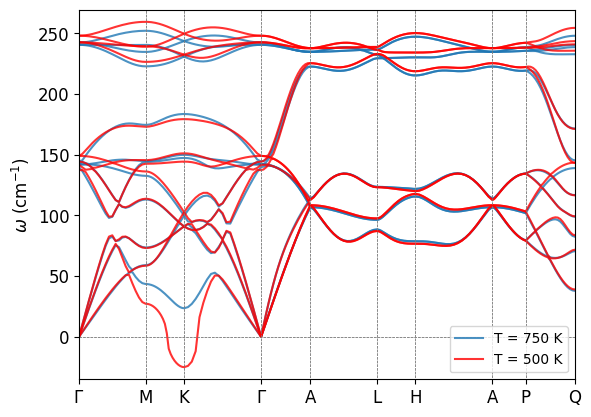

In [10]:
import matplotlib.pyplot as plt
f = plt.figure()
ax = f.add_subplot()
xlabels = [r"$\Gamma$", "M", "K", r"$\Gamma$", "A", "L", "H", "A", "P", "Q"]
mnx.io.plot_bands(ax, qpath, bands_750, xticks, xlabels, label = "T = 750 K")
mnx.io.plot_bands(ax, qpath, bands_500, xticks, xlabels, color="red", label = "T = 500 K")
ax.legend()

In [11]:
dyn500.info()

Lattice information:
	Number of atoms: 4
	Number of atomic species: 2
	Space group: P6_3/mmc (194)
	Cell = [    4.19491234,   -0.00000000,    0.00000000],
	       [   -2.09745617,    3.63290066,    0.00000000],
	       [   -0.00000000,    0.00000000,    4.91210077],
	Atomistic structure:
	        Cr    0.00000000,    0.00000000,    0.00000000
	        Cr    0.00000000,    0.00000000,    2.45605038
	        Sb   -0.00000000,    2.42193377,    1.22802519
	        Sb    2.09745617,    1.21096688,    3.68407558
Dynamical information:
	Number of stars: 4
		Star   0: [    0.00000000,    0.00000000,    0.00000000]


		Star   1: [    0.00000000,    0.00000000,   -0.50000000]


		Star   2: [    0.00000000,   -0.50000000,    0.00000000]
		          [    0.50000000,   -0.00000000,    0.00000000]
		          [   -0.50000000,    0.50000000,    0.00000000]


		Star   3: [    0.00000000,   -0.50000000,   -0.50000000]
		          [    0.50000000,   -0.00000000,    0.50000000]
		          [   -0.500000

# Symmetrize

In [12]:
import mnx

In [13]:
dyn = mnx.DynMatrix.from_file(file="./dyns/CsV3Sb5/dyn_end_population3_", qgrid=[1,1,1], Nqirr=1)

In [14]:
dyn.structure.get_spacegroup(symprec=1e-4)

'Cmmm (65)'

In [15]:
dyn_Fmmm = dyn.copy()

In [16]:
dyn_Fmmm.Symmetrize(symprec=1e-3)

In [17]:
dyn_Fmmm.info()

Lattice information:
	Number of atoms: 72
	Number of atomic species: 3
	Space group: Fmmm (69)
	Cell = [    9.20927571,   -9.52776621,    0.00000000],
	       [    9.20927571,    9.52776621,    0.00000000],
	       [    0.00000000,    0.00000000,   11.00190503],
	Atomistic structure:
	        Cs    4.58234325,   -0.00000000,    5.50095252
	        Cs   13.83620817,   -0.00000000,    5.50095252
	        Cs    4.60463785,    4.76388310,    2.75047626
	        Cs    4.60463785,    4.76388310,    8.25142877
	        Cs   13.79161895,   -0.00000000,    0.00000000
	        Cs    4.62693246,   -0.00000000,    0.00000000
	        Cs    4.60463785,   -4.76388310,    8.25142877
	        Cs    4.60463785,   -4.76388310,    2.75047626
	         V    9.20927571,    2.42345067,    6.80482294
	         V    9.20927571,   -2.42345067,    6.80482294
	         V    0.00000000,    0.00000000,    2.79362643
	         V    9.20927571,   -7.18337947,    6.85529988
	         V    9.20927571,    7.18337947,  

In [18]:
import numpy as np

new_cell = np.array([
    [9.0839022538211438,   -9.5180793956981464,    0.0000000000000000],
    [9.0839022538211438,    9.5180793956981464,    0.0000000000000000],
    [0.0000000000000000,    0.0000000000000000,   10.9775090656828294]])
dyn_Fmmm.change_cell(new_cell)

In [19]:
dyn_Fmmm.structure.rcell

array([[ 0.05504242, -0.05253161,  0.        ],
       [ 0.05504242,  0.05253161,  0.        ],
       [ 0.        ,  0.        ,  0.09109535]])

In [20]:
k_inpath=[
        [[0,0,0],[0.5,0,0]],
        [[0.5,0,0],[0.33333,0.33333,0]],
        [[0.3333, 0.3333, 0], [0, 0, 0]],
        [[0, 0, 0], [0, 0, 0.5]],
        [[0,0,0.5],[0.5,0,0.5]],
        [[0.5,0,0.5],[0.33333,0.33333,0.5]],
        [[0.3333, 0.3333, 0.5], [0, 0, 0.5]],
        [[0, 0, 0.5], [0.25, 0, 0.5]],
        [[0.25, 0, 0.5], [0.25, 0, 0]]
    ]
bands, qpath, xticks = dyn_Fmmm.get_bands(k_inpath=k_inpath,N=20)

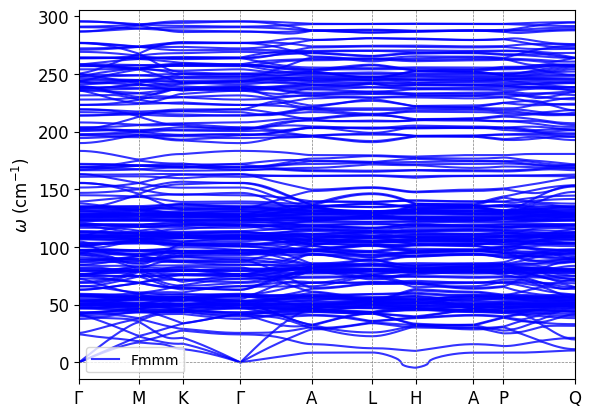

In [21]:
import matplotlib.pyplot as plt

f = plt.figure()
ax = f.add_subplot()
xlabels = [r"$\Gamma$", "M", "K", r"$\Gamma$", "A", "L", "H", "A", "P", "Q"]
mnx.io.plot_bands(ax, qpath, bands, xticks, xlabels, label = "Fmmm", color="blue")
#ax.set_ylim(-10,20)
ax.legend()

In [22]:
dyn_Fmmm.write("./dyns/CsV3Sb5/start.dyn")

In [23]:
dyn_Fmmm.structure.cell

array([[ 9.08390225, -9.5180794 ,  0.        ],
       [ 9.08390225,  9.5180794 ,  0.        ],
       [ 0.        ,  0.        , 10.97750907]])

In [24]:
dyn_Fmmm.DynQs[0].structure.cell

array([[ 9.08390225, -9.5180794 ,  0.        ],
       [ 9.08390225,  9.5180794 ,  0.        ],
       [ 0.        ,  0.        , 10.97750907]])

In [25]:
dyn_Fmmm.structure.get_spacegroup()

'Fmmm (69)'

# RbH12

In [26]:
import mnx

dyn = mnx.DynMatrix.from_file("./dyns/RbH12/3x3x3/hessian", qgrid=[3,3,3], Nqirr=6)

In [27]:
k_inpath=[
        [[0,0,0],[0.5,0,0]],
        [[0.5,0,0],[0.33333,0.33333,0]],
        [[0.3333, 0.3333, 0], [0, 0, 0]],
        [[0, 0, 0], [0, 0, 0.5]],
        [[0,0,0.5],[0.5,0,0.5]],
        [[0.5,0,0.5],[0.33333,0.33333,0.5]],
        [[0.3333, 0.3333, 0.5], [0, 0, 0.5]],
        [[0, 0, 0.5], [0.25, 0, 0.5]],
        [[0.25, 0, 0.5], [0.25, 0, 0]]
    ]
bands, qpath, xticks = dyn.get_bands(k_inpath=k_inpath,N=20)

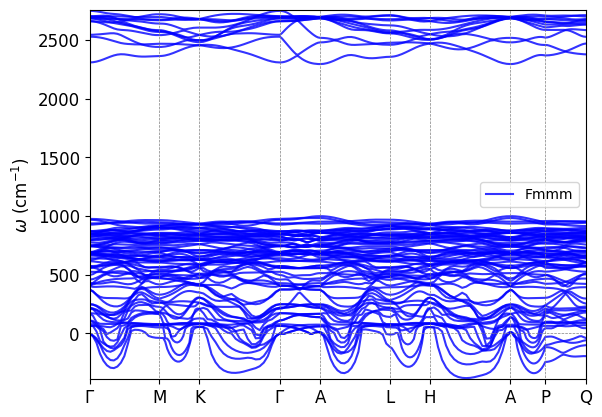

In [28]:
import matplotlib.pyplot as plt

f = plt.figure()
ax = f.add_subplot()
xlabels = [r"$\Gamma$", "M", "K", r"$\Gamma$", "A", "L", "H", "A", "P", "Q"]
mnx.io.plot_bands(ax, qpath, bands, xticks, xlabels, label = "Fmmm", color="blue")
#ax.set_ylim(-10,20)
ax.legend()